# 3b. Experiments — QuadX-Waypoints-v4

This notebook trains and compares three policies on `PyFlyt/QuadX-Waypoints-v4`:

| Agent | Type | Library |
|---|---|---|
| **Random** | Baseline | — |
| **SAC** | Off-policy, entropy-regularised | Custom PyTorch |
| **PPO** | On-policy, clipped surrogate | Stable-Baselines3 |

**Key differences from Hover:**
- Observation is a **Dict** (`attitude` + `target_deltas`) → must be flattened to a Box before feeding any algorithm
- Reward is **sparse + shaped**: small step penalty every tick, large bonus on waypoint reach — harder credit assignment than Hover's dense signal
- Episode success is measurable: we track how many of the 4 waypoints are reached per episode

**Flight mode:** `6` (ground velocity + yaw + vertical — easy enough to learn navigation, hard enough to be interesting).

## 0. Imports & config

In [1]:
import numpy as np
import gymnasium as gym
import PyFlyt.gym_envs
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from algorithms import SACAgent, PPOAgent, evaluate_policy

from scripts.wrappers import FlattenWaypointEnv
def make_env():
    return FlattenWaypointEnv(gym.make(ENV_ID, **ENV_KWARGS), max_waypoints=4)

# ── reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── environment config ───────────────────────────────────────
ENV_ID      = "PyFlyt/QuadX-Waypoints-v4"
FLIGHT_MODE = 6
ENV_KWARGS  = dict(
    flight_mode         = FLIGHT_MODE,
    goal_reach_distance = 4.0,
    flight_dome_size    = 150.0,
    max_duration_seconds= 120.0,
    num_targets         = 4,
)

# ── eval config ──────────────────────────────────────────────
MAX_STEPS  = 1000       # waypoints episodes can be long (120 s × ~8 Hz)
EVAL_EPS   = 10
EVAL_SEEDS = list(range(SEED, SEED + EVAL_EPS))

# ── obs/action dims (after flattening) ───────────────────────
_env_tmp   = make_env()
obs, _     = _env_tmp.reset(seed=42)
STATE_DIM  = _env_tmp.observation_space.shape[0]   # 33
ACTION_DIM = _env_tmp.action_space.shape[0]         # 4
ACTION_LOW  = _env_tmp.action_space.low
ACTION_HIGH = _env_tmp.action_space.high
_env_tmp.close()

print(f"Environment : {ENV_ID}  |  flight_mode = {FLIGHT_MODE}")
print(f"State dim   : {STATE_DIM}  (21 attitude + 4×3 waypoint deltas)")
print(f"Action dim  : {ACTION_DIM}")
print(f"Device      : {'cuda' if torch.cuda.is_available() else 'cpu'}")

                             
Environment : PyFlyt/QuadX-Waypoints-v4  |  flight_mode = 6
State dim   : 33  (21 attitude + 4×3 waypoint deltas)
Action dim  : 4
Device      : cuda


## 1. Observation flattening

The Waypoints environment returns a **Dict** observation:
```
{'attitude': ndarray(21,), 'target_deltas': ndarray(4, 3)}
```
Neither SAC (which concatenates obs with action) nor PPO (MlpPolicy) accepts a Dict directly.
We wrap every environment instance with `gym.wrappers.FlattenObservation`, which concatenates all
Dict values into a single `ndarray(33,)` automatically.

The shared `eval_agent` helper below creates the env + wrapper in one place so every agent
sees the same flattened observation.

In [2]:
def flatten_obs(obs: dict) -> np.ndarray:
    """Concatenate all Dict observation values into a single flat vector."""
    return np.concatenate([v.flatten() for v in obs.values()])

def eval_agent(policy_fn, label, n_episodes=EVAL_EPS, seeds=EVAL_SEEDS, max_steps=MAX_STEPS):
    env = make_env()
    returns = []

    for seed in tqdm(seeds, desc=f"Eval [{label}]"):
        obs, _ = env.reset(seed=seed)
        total  = 0.0
        for _ in range(max_steps):
            action = policy_fn(obs)    # obs is already a flat ndarray
            obs, reward, terminated, truncated, _ = env.step(action)
            total += reward
            if terminated or truncated:
                break
        returns.append(total)

    env.close()
    mean, std = float(np.mean(returns)), float(np.std(returns))
    print(f"  {label:<12}  mean={mean:8.2f}  std={std:7.2f}")
    return mean, std, returns

## 2. Random baseline

In [3]:
_env_tmp = make_env()
_action_space = _env_tmp.action_space
_env_tmp.close()

rand_mean, rand_std, rand_returns = eval_agent(
    lambda obs: _action_space.sample(), "Random"
)

Eval [Random]:   0%|          | 0/10 [00:00<?, ?it/s]

Eval [Random]:  10%|█         | 1/10 [00:02<00:22,  2.54s/it]

Eval [Random]:  20%|██        | 2/10 [00:04<00:19,  2.48s/it]

Eval [Random]:  30%|███       | 3/10 [00:07<00:17,  2.46s/it]

Eval [Random]:  40%|████      | 4/10 [00:09<00:14,  2.47s/it]

...

Eval [Random]:  70%|███████   | 7/10 [00:18<00:08,  2.78s/it]

Eval [Random]:  80%|████████  | 8/10 [00:21<00:05,  2.78s/it]

Eval [Random]:  90%|█████████ | 9/10 [00:23<00:02,  2.71s/it]

Eval [Random]: 100%|██████████| 10/10 [00:26<00:00,  2.62s/it]

  Random        mean= -161.98  std=   9.51


## 3. SAC — Soft Actor-Critic

### 3.1 What changes vs Hover

- **Sparse reward**: SAC's replay buffer will initially fill with transitions where reward ≈ 0 (no waypoint reached). The critic needs more data before it can distinguish good from bad actions. We therefore train for more episodes than on Hover.
- **Reward normalisation**: enabled by default in `SACAgent` — especially important here because the waypoint bonus is a large positive spike surrounded by many near-zero step penalties, giving a very skewed reward distribution.
- **State dim 33** instead of 21: the extra 12 dimensions are the 4 waypoint deltas, which give the policy direct goal information.

### 3.2 Hyperparameters

In [4]:
SAC_EPISODES   = 500    # more episodes — sparse reward needs more data
SAC_MAX_STEPS  = 1000   # match eval horizon
SAC_BATCH_SIZE = 256
SAC_GAMMA      = 0.99
SAC_TAU        = 0.005
SAC_ALPHA      = 0.2
SAC_LR         = 3e-4
SAC_BUFFER     = 500_000

### 3.3 Training loop

In [5]:
env_sac = make_env()

sac = SACAgent(
    state_dim        = STATE_DIM,
    action_dim       = ACTION_DIM,
    action_low       = ACTION_LOW,
    action_high      = ACTION_HIGH,
    gamma            = SAC_GAMMA,
    tau              = SAC_TAU,
    alpha            = SAC_ALPHA,
    lr               = SAC_LR,
    buffer_size      = SAC_BUFFER,
    normalize_rewards= True,   # critical for sparse waypoint reward
)

sac_train_returns = []

for ep in tqdm(range(SAC_EPISODES), desc="Training SAC"):
    obs, _ = env_sac.reset(seed=SEED + ep)
    ep_reward = 0.0

    for _ in range(SAC_MAX_STEPS):
        a_norm = sac.act(obs, deterministic=False)
        a_env  = sac.env_action(obs, deterministic=False)

        next_obs, reward, terminated, truncated, _ = env_sac.step(a_env)
        done = terminated or truncated

        sac.store(obs, a_norm, reward, next_obs, float(done))
        sac.update(batch_size=SAC_BATCH_SIZE)

        obs        = next_obs
        ep_reward += reward
        if done:
            break

    sac_train_returns.append(ep_reward)

env_sac.close()
print(f"\nSAC training done. Last-20 mean: {np.mean(sac_train_returns[-20:]):.2f}")

Training SAC:   0%|          | 0/500 [00:00<?, ?it/s]

Training SAC:   0%|          | 1/500 [00:16<2:19:52, 16.82s/it]

Training SAC:   0%|          | 2/500 [00:34<2:25:45, 17.56s/it]

Training SAC:   1%|          | 3/500 [00:52<2:26:41, 17.71s/it]

Training SAC:   1%|          | 4/500 [01:10<2:25:19, 17.58s/it]

...

Training SAC:  99%|█████████▉| 497/500 [2:35:27<00:55, 18.63s/it]

Training SAC: 100%|█████████▉| 498/500 [2:35:49<00:39, 19.61s/it]

Training SAC: 100%|█████████▉| 499/500 [2:36:10<00:20, 20.25s/it]

Training SAC: 100%|██████████| 500/500 [2:36:32<00:00, 18.79s/it]


SAC training done. Last-20 mean: -164.41


In [6]:
import scripts.wrappers as w
import inspect
print(inspect.getsource(w))

"""Custom Gymnasium wrappers for PyFlyt environments."""

import gymnasium
import numpy as np
from gymnasium import spaces


class FlattenWaypointEnv(gymnasium.ObservationWrapper):
    """Flattens the Dict observation of PyFlyt Waypoints envs into a single Box.

    The Waypoints env returns:
      - 'attitude': Box(21,) - drone state
      - 'target_deltas': (N, 3) waypoint deltas — N can decrease as waypoints are reached

    This wrapper pads/truncates target_deltas to a fixed number of waypoints
    and concatenates everything into a single flat vector.
    """

    def __init__(self, env, max_waypoints=4):
        super().__init__(env)
        self.max_waypoints = max_waypoints

        # Determine attitude dim from the observation space
        self.attitude_dim = env.observation_space["attitude"].shape[0]
        total_dim = self.attitude_dim + self.max_waypoints * 3

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(total_dim,), dtype=np.

### 3.4 Evaluate SAC

In [7]:
sac_mean, sac_std, sac_returns = eval_agent(
    lambda obs: sac.predict(obs, deterministic=True)[0], "SAC"
)

Eval [SAC]:   0%|          | 0/10 [00:00<?, ?it/s]

Eval [SAC]:  10%|█         | 1/10 [00:03<00:31,  3.52s/it]

Eval [SAC]:  20%|██        | 2/10 [00:06<00:27,  3.44s/it]

Eval [SAC]:  30%|███       | 3/10 [00:07<00:13,  2.00s/it]

Eval [SAC]:  40%|████      | 4/10 [00:07<00:08,  1.36s/it]

...

Eval [SAC]:  70%|███████   | 7/10 [00:14<00:05,  1.75s/it]

Eval [SAC]:  80%|████████  | 8/10 [00:17<00:04,  2.20s/it]

Eval [SAC]:  90%|█████████ | 9/10 [00:20<00:02,  2.54s/it]

Eval [SAC]: 100%|██████████| 10/10 [00:21<00:00,  2.14s/it]

  SAC           mean= -125.27  std=  24.28


### 3.5 Training curve — SAC

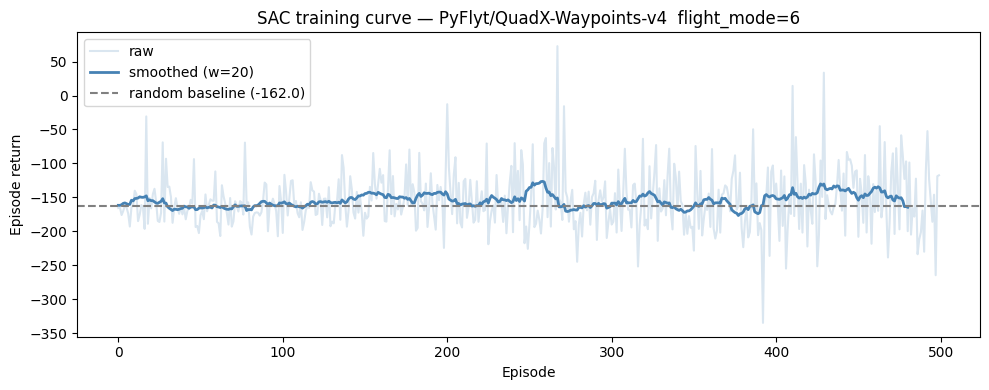

In [8]:
def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sac_train_returns, alpha=0.2, color='steelblue', label='raw')
ax.plot(range(len(smooth(sac_train_returns))), smooth(sac_train_returns),
        color='steelblue', lw=2, label='smoothed (w=20)')
ax.axhline(rand_mean, color='grey', linestyle='--',
           label=f'random baseline ({rand_mean:.1f})')
ax.set_xlabel('Episode')
ax.set_ylabel('Episode return')
ax.set_title(f'SAC training curve — {ENV_ID}  flight_mode={FLIGHT_MODE}')
ax.legend()
plt.tight_layout()
plt.show()

## 4. PPO — Proximal Policy Optimisation

### 4.1 What changes vs Hover

PPO's GAE advantage estimate naturally handles sparse rewards because it accumulates TD errors along the full rollout (`n_steps=2048` steps). A waypoint bonus collected 200 steps into the episode propagates back to earlier decisions through the discounted advantage. This makes PPO relatively robust to reward sparsity without any special modification.

SB3's PPO also accepts `FlattenObservation`-wrapped environments directly, so no extra changes are needed.

### 4.2 Hyperparameters

In [9]:
PPO_TIMESTEPS = 500_000   # match SAC's episode budget × steps
PPO_N_STEPS   = 2048
PPO_BATCH     = 64
PPO_EPOCHS    = 10
PPO_GAMMA     = 0.99
PPO_GAE       = 0.95
PPO_CLIP      = 0.2
PPO_LR        = 3e-4

### 4.3 Training

In [10]:
env_ppo = make_env()

ppo = PPOAgent(
    env          = env_ppo,
    learning_rate= PPO_LR,
    n_steps      = PPO_N_STEPS,
    batch_size   = PPO_BATCH,
    n_epochs     = PPO_EPOCHS,
    gamma        = PPO_GAMMA,
    gae_lambda   = PPO_GAE,
    clip_range   = PPO_CLIP,
    verbose      = 1,
    seed         = SEED,
)

ppo.train(total_timesteps=PPO_TIMESTEPS)
env_ppo.close()

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


f:\Dev\anaconda\envs\rl\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


                             
-----------------------------
| time/              |      |
|    fps             | 226  |
|    iterations      | 1    |
|    time_elapsed    | 9    |
|    total_timesteps | 2048 |
-----------------------------                             
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.6e+03     |
|    ep_rew_mean          | -331        |
| time/                   |             |
|    fps                  | 204         |
|    iterations           | 2           |
|    time_elapsed         | 20          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013151871 |
|    clip_fraction        | 0.14        |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.64       |
|    explained_variance   | 0.425       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0103      |
|    n_updates   

### 4.4 Evaluate PPO

In [11]:
ppo_mean, ppo_std, ppo_returns = eval_agent(
    lambda obs: ppo.predict(obs, deterministic=True)[0], "PPO"
)

Eval [PPO]:   0%|          | 0/10 [00:00<?, ?it/s]

Eval [PPO]:  10%|█         | 1/10 [00:03<00:34,  3.84s/it]

Eval [PPO]:  20%|██        | 2/10 [00:07<00:29,  3.71s/it]

Eval [PPO]:  30%|███       | 3/10 [00:11<00:25,  3.64s/it]

Eval [PPO]:  40%|████      | 4/10 [00:14<00:21,  3.53s/it]

...

Eval [PPO]:  70%|███████   | 7/10 [00:24<00:10,  3.40s/it]

Eval [PPO]:  80%|████████  | 8/10 [00:27<00:06,  3.36s/it]

Eval [PPO]:  90%|█████████ | 9/10 [00:31<00:03,  3.36s/it]

Eval [PPO]: 100%|██████████| 10/10 [00:34<00:00,  3.44s/it]

  PPO           mean=  -51.07  std=  18.85


## 5. Results summary

### 5.1 Numerical table

In [12]:
print(f"{'Agent':<14} {'Mean return':>14} {'Std':>10} {'95% CI':>22}")
print("-" * 64)
for label, mean, std, rets in [
    ("Random", rand_mean, rand_std, rand_returns),
    ("SAC",    sac_mean,  sac_std,  sac_returns),
    ("PPO",    ppo_mean,  ppo_std,  ppo_returns),
]:
    n    = len(rets)
    se   = std / np.sqrt(n)
    ci_lo = mean - 1.96 * se
    ci_hi = mean + 1.96 * se
    print(f"{label:<14} {mean:>14.2f} {std:>10.2f}  [{ci_lo:9.2f}, {ci_hi:9.2f}]")

Agent             Mean return        Std                 95% CI
----------------------------------------------------------------
Random                -161.98       9.51  [  -167.88,   -156.09]
SAC                   -125.27      24.28  [  -140.32,   -110.22]
PPO                    -51.07      18.85  [   -62.75,    -39.39]


### 5.2 Bar chart with error bars

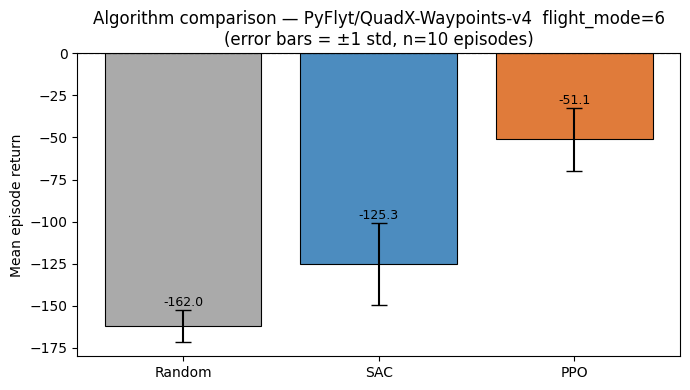

In [13]:
labels  = ["Random", "SAC", "PPO"]
means   = [rand_mean, sac_mean, ppo_mean]
stds    = [rand_std,  sac_std,  ppo_std]
colors  = ["#aaaaaa", "#4c8cbf", "#e07b3a"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, means, yerr=stds, capsize=6,
              color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Mean episode return')
ax.set_title(
    f'Algorithm comparison — {ENV_ID}  flight_mode={FLIGHT_MODE}\n'
    f'(error bars = ±1 std, n={EVAL_EPS} episodes)'
)
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            mean + std + 0.5, f'{mean:.1f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 5.3 Return distribution (box plot)

C:\Users\Megaport\AppData\Local\Temp\ipykernel_12392\1045663758.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


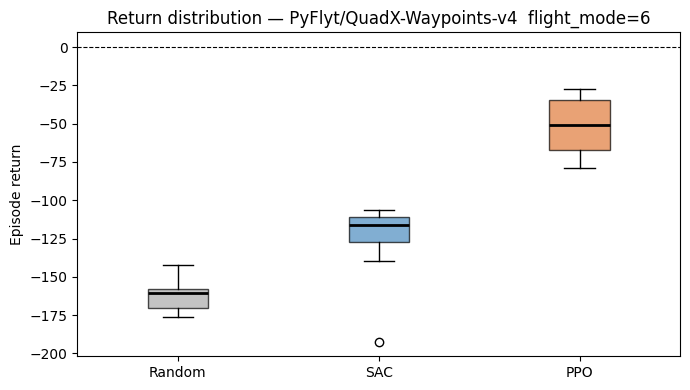

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot(
    [rand_returns, sac_returns, ppo_returns],
    labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Episode return')
ax.set_title(f'Return distribution — {ENV_ID}  flight_mode={FLIGHT_MODE}')
plt.tight_layout()
plt.show()

### 5.4 SAC training curve vs baselines

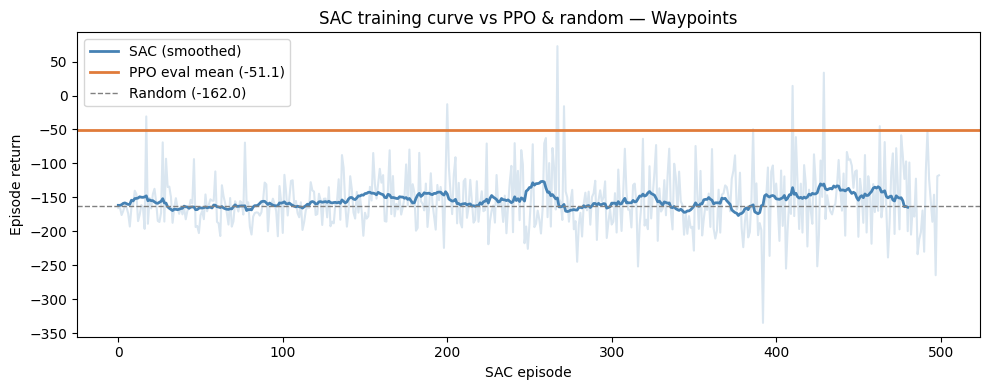

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sac_train_returns, alpha=0.2, color='steelblue')
ax.plot(smooth(sac_train_returns), color='steelblue', lw=2, label='SAC (smoothed)')
ax.axhline(ppo_mean,  color='#e07b3a', lw=2, label=f'PPO eval mean ({ppo_mean:.1f})')
ax.axhline(rand_mean, color='grey', linestyle='--', lw=1, label=f'Random ({rand_mean:.1f})')
ax.set_xlabel('SAC episode')
ax.set_ylabel('Episode return')
ax.set_title('SAC training curve vs PPO & random — Waypoints')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Save models

In [16]:
import os
os.makedirs("checkpoints", exist_ok=True)

torch.save({
    'actor': sac.actor.state_dict(),
    'q1':    sac.q1.state_dict(),
    'q2':    sac.q2.state_dict(),
    'q1_t':  sac.q1_t.state_dict(),
    'q2_t':  sac.q2_t.state_dict(),
    'reward_norm_mean':  sac._reward_norm.mean,
    'reward_norm_var':   sac._reward_norm.var,
    'reward_norm_count': sac._reward_norm.count,
}, "checkpoints/sac_waypoints_mode6.pt")

ppo.save("checkpoints/ppo_waypoints_mode6")
print("Saved to ./checkpoints/")

Saved to ./checkpoints/


## 7. Reload & verify

In [17]:
# ── reload SAC ───────────────────────────────────────────────
sac_loaded = SACAgent(
    state_dim   = STATE_DIM,
    action_dim  = ACTION_DIM,
    action_low  = ACTION_LOW,
    action_high = ACTION_HIGH,
)
ckpt = torch.load("checkpoints/sac_waypoints_mode6.pt", map_location='cpu')
sac_loaded.actor.load_state_dict(ckpt['actor'])
sac_loaded.q1.load_state_dict(ckpt['q1'])
sac_loaded.q2.load_state_dict(ckpt['q2'])
# restore normaliser state so predict() behaviour is identical
sac_loaded._reward_norm.mean  = ckpt['reward_norm_mean']
sac_loaded._reward_norm.var   = ckpt['reward_norm_var']
sac_loaded._reward_norm.count = ckpt['reward_norm_count']

sac_rl_mean, _, _ = eval_agent(
    lambda obs: sac_loaded.predict(obs, deterministic=True)[0], "SAC (reloaded)"
)

# ── reload PPO ───────────────────────────────────────────────
env_reload = make_env()
ppo_loaded = PPOAgent.load("checkpoints/ppo_waypoints_mode6", env=env_reload)
ppo_rl_mean, _, _ = eval_agent(
    lambda obs: ppo_loaded.predict(obs, deterministic=True)[0], "PPO (reloaded)"
)
env_reload.close()

print(f"\nSanity check:")
print(f"  SAC  original={sac_mean:.2f}  reloaded={sac_rl_mean:.2f}")
print(f"  PPO  original={ppo_mean:.2f}  reloaded={ppo_rl_mean:.2f}")

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy.core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn mor